# Chapter 2: Primer on Probability Theory — Exercises

Each exercise: statement → derivation (markdown) → numerical/symbolic check (code).

In [1]:
using Pkg; Pkg.activate(joinpath(@__DIR__, ".."))
using LinearAlgebra, Distributions, Random, Plots

  Activating project at `~/l/barfoot`


## Exercise 2.1

Show for any two columns of the same length, $\mathbf{u}$ and $\mathbf{v}$, that

$$\mathbf{u}^T \mathbf{v} = \operatorname{tr}\left(\mathbf{v}\mathbf{u}^T\right).$$

In [2]:
# Ex 2.1 check
u = randn(10)
v = randn(10)

uv = u' * v
vu = v * u'

uv == tr(vu)
@assert isapprox(uv, tr(vu); atol = 0e-15)



## Exercise 2.2

Show that if two random variables, $\mathbf{x}$ and $\mathbf{y}$, are statistically independent, then the Shannon information of the joint density, $p(\mathbf{x}, \mathbf{y})$, is the sum of the Shannon informations of the individual densities, $p(\mathbf{x})$ and $p(\mathbf{y})$:

$$H(\mathbf{x}, \mathbf{y}) = H(\mathbf{x}) + H(\mathbf{y}).$$

In [3]:
# Ex 2.2 check
x_dist = Normal(0.0, 1.0)
x = rand(x_dist, 100_000)
lpx = logpdf.(x_dist, x)
h_x = -mean(lpx)
@assert isapprox(h_x, entropy(x_dist); atol = 0.01)

y_dist = Uniform(0.5, 2.0)
y = rand(y_dist, 100_000)
lpy = logpdf.(y_dist, y)
h_y = -mean(lpy)
@assert isapprox(h_y, entropy(y_dist); atol = 0.01)

xy_dist = product_distribution([x_dist, y_dist])
xy = permutedims(hcat(x, y))
h_xy = - mean(logpdf(xy_dist, xy))
@assert isapprox(h_xy, h_x + h_y; atol = 0.01)
@assert isapprox(h_xy, entropy(xy_dist); atol = 0.01)

## Exercise 2.3

For a Gaussian random variable, $\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, show that

$$E\left[\mathbf{x}\mathbf{x}^T\right] = \boldsymbol{\Sigma} + \boldsymbol{\mu}\boldsymbol{\mu}^T.$$

In [4]:
# Ex 2.3 check
Random.seed!(3)
μ = randn(3)
A = randn(3, 3); Σ = Symmetric(A * A')
x_dist = MvNormal(μ, Σ)
x = rand(x_dist, 10_000)

E_xx = x * x' / size(x, 2)
E_xx_true = Σ + μ * μ'

@assert isapprox(E_xx, E_xx_true; rtol = 0.02)


## Exercise 2.4 _(2ed new)_

For a Gaussian random variable, $\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, determine expressions for

$$E\left[\mathbf{x}^T\mathbf{x}\right] \quad \text{and} \quad E\left[\mathbf{x}\mathbf{x}^T\right]$$

in terms of the mean, $\boldsymbol{\mu}$, and covariance matrix, $\boldsymbol{\Sigma}$.

In [ ]:
# Ex 2.4 check
Random.seed!(4)
μ = [0.5, -1.0, 2.0]
Σ = [0.04 0.01 0.0;
     0.01 0.09 0.0;
     0.0  0.0  0.25]

x = rand(MvNormal(μ, Σ), n)
n = 100_000
E_xxT = x * x' / n  
E_xTx = mean(sum(abs2, x, dims=1))  

@assert isapprox(E_xxT, Σ + μ * μ'; rtol = 0.01)
@assert isapprox(E_xTx, tr(Σ) + μ' * μ; rtol = 0.01)
@assert E_xTx ≈ tr(E_xxT)


LoadError: AssertionError: isapprox(E_xxT, Σ + μ * μ'; rtol = 0.01)

## Exercise 2.5 _(2ed new)_

For a joint Gaussian

$$p(\mathbf{x}, \mathbf{y}) = \mathcal{N}\left(\begin{bmatrix} \boldsymbol{\mu}_x \\ \boldsymbol{\mu}_y \end{bmatrix}, \begin{bmatrix} \boldsymbol{\Sigma}_{xx} & \boldsymbol{\Sigma}_{xy} \\ \boldsymbol{\Sigma}_{yx} & \boldsymbol{\Sigma}_{yy} \end{bmatrix}\right),$$

use marginalization to compute $p(\mathbf{x})$ and $p(\mathbf{y})$. Under what conditions does

$$p(\mathbf{x}, \mathbf{y}) = p(\mathbf{x})\,p(\mathbf{y})$$

hold?

### Derivation

Gaussian: x, y independent  ⇔  Σ_xy = 0
Marginal (always valid): p(x) = ∫ p(x,y) dy

In [6]:
# Ex 2.5 check
xy_mean = [0.5, 0.2]
xy_cov = [0.99^2 0.05; 0.05 0.2^2]
xy_dist = MvNormal(xy_mean, xy_cov)
xy = rand(xy_dist, 100_000)
x = xy[1, :]
x_mean = mean(x)
x_cov = cov(x)

y = xy[2, :]
y_mean = mean(y)
y_cov = cov(y)

println(x_mean)
println(x_cov)
println(y_mean)
println(y_cov)

0.49904576195984146
0.980926033917326
0.19963717658571145
0.040022964922442776


## Exercise 2.6

For a Gaussian random variable, $\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, show directly that

$$\boldsymbol{\mu} = E[\mathbf{x}] = \int_{-\infty}^{\infty} \mathbf{x}\, p(\mathbf{x})\, d\mathbf{x}.$$

In [7]:
# Ex 2.6 check

μ = 0.35
σ = 0.99

dist = Normal(μ, σ)
x = rand(dist, 100_000)

E_x = mean(x)

delta_x = 1e-3
grid = μ - 10σ:delta_x:μ + 10σ
E_x = sum(grid .* pdf.(dist, grid)) * delta_x
@assert isapprox(E_x, μ; atol = 0.01)


## Exercise 2.7

For a Gaussian random variable, $\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, show directly that

$$\boldsymbol{\Sigma} = E\left[(\mathbf{x} - \boldsymbol{\mu})(\mathbf{x} - \boldsymbol{\mu})^T\right] = \int_{-\infty}^{\infty} (\mathbf{x} - \boldsymbol{\mu})(\mathbf{x} - \boldsymbol{\mu})^T p(\mathbf{x})\, d\mathbf{x}.$$

In [8]:
# Ex 2.7 check
μ = [0.35, -0.2]
Σ = [0.99 0.0; 0.0 0.2]

dist = MvNormal(μ, Σ)
x = rand(dist, 10_000)
d = x .- μ
E_cov = d * d' / (size(x, 2) - 1)
@assert isapprox(E_cov, Σ; atol = 0.1)

σ = sqrt.(diag(Σ))
h= 0.01
g1 = μ[1]-8σ[1]:h:μ[1]+8σ[1]
g2 = μ[2]-8σ[2]:h:μ[2]+8σ[2]
E_cov_int = zeros(2, 2)
for a in g1, b in g2
    d = [a, b] - μ
    E_cov_int += d * d' * pdf(dist, [a, b])
end
E_cov_int *= h^2 
@assert isapprox(E_cov_int, Σ; atol = 1e-6)



## Exercise 2.8

Show that the normalized product of $K$ statistically independent Gaussian PDFs, $\mathbf{x}_k \sim \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$, is also a Gaussian PDF:

$$\exp\left(-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})\right) \equiv \eta \prod_{k=1}^{K} \exp\left(-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_k)^T \boldsymbol{\Sigma}_k^{-1} (\mathbf{x} - \boldsymbol{\mu}_k)\right),$$

where

$$\boldsymbol{\Sigma}^{-1} = \sum_{k=1}^{K} \boldsymbol{\Sigma}_k^{-1}, \qquad \boldsymbol{\Sigma}^{-1}\boldsymbol{\mu} = \sum_{k=1}^{K} \boldsymbol{\Sigma}_k^{-1}\boldsymbol{\mu}_k,$$

and $\eta$ is a normalization constant to enforce the axiom of total probability.

In [9]:
# Ex 2.8 check
μ_one = 0.35
σ_one = 1

μ_two = -0.2
σ_two = 2

d1 = Normal(μ_one, σ_one)
d2 = Normal(μ_two, σ_two)

delta = 1e-3
grid = -25:delta:25
prod_pdf = pdf.(d1, grid) .* pdf.(d2, grid)
prod_pdf /= sum(prod_pdf) * delta

μ_num = sum(grid .* prod_pdf) * delta
var_num = sum((grid .- μ_num).^2 .* prod_pdf) * delta

var_f = 1/ (1/1^2 + 1/2^2)
μ_f = var_f * (μ_one/1^2 + μ_two/2^2)

@assert isapprox(μ_num, μ_f; atol = 1e-6)    
@assert isapprox(var_num, var_f; atol = 1e-6) 


## Exercise 2.9

Consider $K$ random variables, $\mathbf{x}_k$, with PDFs, $p_k(\mathbf{x})$, and means, $\boldsymbol{\mu}_k$. Let $\mathbf{x}$ be the random variable whose PDF is the weighted sum

$$p(\mathbf{x}) = \sum_{k=1}^{K} w_k\, p_k(\mathbf{x}),$$

with $\sum_{k=1}^{K} w_k = 1$ and $w_k \geq 0$. Show that $p(\mathbf{x})$ satisfies the axiom of total probability and that the mean of $\mathbf{x}$ is given by

$$\boldsymbol{\mu} = \sum_{k=1}^{K} w_k \boldsymbol{\mu}_k.$$

Determine an expression for the covariance. Note that the random variables are not assumed to be Gaussian.

In [10]:
# Ex 2.9 check
d1 = Normal(0, 1)
d2 = Normal(1, 2)
d3 = Normal(2, 3)
ds = [d1, d2, d3]

w1 = 0.1
w2 = 0.4
w3 = 0.5
ws = [w1, w2, w3]
@assert isapprox(sum(ws), 1; atol = 1e-8)

delta = 0.001
grid = -30:delta:30

p = w1 * pdf.(d1, grid) + w2 * pdf.(d2, grid) + w3 * pdf.(d3, grid)
area = sum(p) * delta
mu_num = sum(grid .* p) * delta
var_num = sum((grid .- mu_num).^2 .* p) * delta

mu_f = sum(w * mean(d) for (w, d) in zip(ws, ds))    
var_f = sum(w * (var(d) + mean(d)^2) for (w, d) in zip(ws, ds)) - mu_f^2

@assert isapprox(area, 1; atol = 1e-8)
@assert isapprox(mu_num, mu_f; atol = 1e-8)
@assert isapprox(var_num, var_f; atol = 1e-6)



## Exercise 2.10

The random variable

$$y = \mathbf{x}^T\mathbf{x}$$

is chi-squared (of order $K$) when $\mathbf{x} \sim \mathcal{N}(\mathbf{0}, \mathbf{1})$ is length $K$. Show that the mean and variance are given by $K$ and $2K$, respectively. Hint: use Isserlis' theorem.

### Derivation

$y = \mathbf{x}^T\mathbf{x} = \sum_{i=1}^{K} x_i^2$, with $\mathbf{x} \sim \mathcal{N}(\mathbf{0}, \mathbf{1})$, so $E[x_i x_j] = \delta_{ij}$.

**Mean** (no Isserlis needed):

$$E[y] = \sum_i E[x_i^2] = \sum_i 1 = K.$$

**Second moment** — requires the 4th moment $E[x_i^2 x_j^2]$:

$$E[y^2] = E\Big[\sum_i x_i^2 \sum_j x_j^2\Big] = \sum_{i,j} E[x_i x_i x_j x_j].$$

**Isserlis' theorem** (zero-mean Gaussian): sum over all pairings of the four indices,

$$E[x_a x_b x_c x_d] = E[x_a x_b]E[x_c x_d] + E[x_a x_c]E[x_b x_d] + E[x_a x_d]E[x_b x_c].$$

For $(a,b,c,d) = (i,i,j,j)$:

$$E[x_i x_i x_j x_j] = \delta_{ii}\delta_{jj} + \delta_{ij}\delta_{ij} + \delta_{ij}\delta_{ij} = 1 + 2\delta_{ij}.$$

(e.g. $i = j$: $E[x^4] = 3$.) Summing over $i, j$: the $1$'s give $K^2$, the $2\delta_{ij}$ give $2K$:

$$E[y^2] = K^2 + 2K.$$

**Variance:**

$$\operatorname{Var}[y] = E[y^2] - E[y]^2 = K^2 + 2K - K^2 = 2K.$$

In [ ]:
# Ex 2.10 check
μ = zeros(5)
Σ = Diagonal(ones(5))
K = length(μ)

x_dist = MvNormal(μ, Σ)
x = rand(x_dist, 100_000)
y = vec(sum(abs2, x, dims = 1))


@assert isapprox(mean(y), K; rtol = 0.02)
@assert isapprox(var(y), 2K; rtol = 0.05)






## Exercise 2.11 _(2ed new)_

Consider the random variable

$$y = (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}),$$

where $\mathbf{x} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is length $K$. Show that the variance of $y$ is $2K$. Hint: use Isserlis' theorem.

### Derivation

Let $\mathbf{d} = \mathbf{x} - \boldsymbol{\mu} \sim \mathcal{N}(\mathbf{0}, \boldsymbol{\Sigma})$ and $\mathbf{A} = \boldsymbol{\Sigma}^{-1}$ (symmetric), so

$$y = \mathbf{d}^T\mathbf{A}\mathbf{d} = \sum_{i,j} A_{ij}\, d_i d_j, \qquad E[d_i d_j] = \Sigma_{ij}.$$

**Mean:**

$$E[y] = \sum_{i,j} A_{ij}\Sigma_{ji} = \operatorname{tr}(\mathbf{A}\boldsymbol{\Sigma}) = \operatorname{tr}(\mathbf{1}) = K.$$

**Second moment** — requires the 4th moment of $\mathbf{d}$:

$$E[y^2] = \sum_{i,j,k,l} A_{ij} A_{kl}\, E[d_i d_j d_k d_l].$$

**Isserlis' theorem** (zero-mean Gaussian):

$$E[d_i d_j d_k d_l] = \Sigma_{ij}\Sigma_{kl} + \Sigma_{ik}\Sigma_{jl} + \Sigma_{il}\Sigma_{jk}.$$

Each term collapses to a trace (using $\mathbf{A}^T = \mathbf{A}$, $\boldsymbol{\Sigma}^T = \boldsymbol{\Sigma}$):

$$\sum A_{ij}A_{kl}\Sigma_{ij}\Sigma_{kl} = \operatorname{tr}(\mathbf{A}\boldsymbol{\Sigma})^2 = K^2,$$
$$\sum A_{ij}A_{kl}\Sigma_{ik}\Sigma_{jl} = \sum A_{ij}A_{kl}\Sigma_{il}\Sigma_{jk} = \operatorname{tr}(\mathbf{A}\boldsymbol{\Sigma}\mathbf{A}\boldsymbol{\Sigma}) = \operatorname{tr}(\mathbf{1}) = K.$$

So

$$E[y^2] = K^2 + 2K.$$

**Variance:**

$$\operatorname{Var}[y] = E[y^2] - E[y]^2 = K^2 + 2K - K^2 = 2K.$$

Same structure as 2.10, with $\mathbf{A}\boldsymbol{\Sigma} = \mathbf{1}$ playing the role of $\delta_{ij}$, so $\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}$ drop out. By-product for any symmetric $\mathbf{A}$: $\operatorname{Var}[\mathbf{d}^T\mathbf{A}\mathbf{d}] = 2\operatorname{tr}(\mathbf{A}\boldsymbol{\Sigma}\mathbf{A}\boldsymbol{\Sigma})$.

In [12]:
# Ex 2.11 check
Random.seed!(11) 
μ = [0.1, 0.2, 0.3, 0.4, 0.5]
A = randn(5, 5)
Σ = Symmetric(A * A' + 0.1I) # Non diagonal
K = length(μ)

x_dist = MvNormal(μ, Σ)
x = rand(x_dist, 100_000)
d = x .- μ
y = vec(sum(d .* (Σ \ d), dims = 1))

var_y = var(y)
@assert isapprox(var_y, 2K; rtol = 0.05)
L = cholesky(Σ).L
z = L \ d
cov(z, dims=2)

quantile(Chisq(K), 0.99)
mean(y .> quantile(Chisq(K), 0.99))

0.01009

## Exercise 2.12 _(2ed new)_

Consider two Gaussian PDFs with a common dimension of $N$, $p_1(\mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)$ and $p_2(\mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}_2, \boldsymbol{\Sigma}_2)$. Show that the KL divergence is

$$\mathrm{KL}(p_2 \| p_1) = \frac{1}{2}\left((\boldsymbol{\mu}_2 - \boldsymbol{\mu}_1)^T \boldsymbol{\Sigma}_1^{-1} (\boldsymbol{\mu}_2 - \boldsymbol{\mu}_1) + \ln\left|\boldsymbol{\Sigma}_1 \boldsymbol{\Sigma}_2^{-1}\right| + \operatorname{tr}\left(\boldsymbol{\Sigma}_1^{-1}\boldsymbol{\Sigma}_2\right) - N\right).$$

In [13]:
# Ex 2.12 check
Random.seed!(121) 
μ1 = [0.1, 0.2, 0.3, 0.4, 0.5]
A1 = randn(5, 5)
Σ1 = Symmetric(A1 * A1' + 0.1I) 
Random.seed!(122) 
μ2 = [0.055, 0.02, 0.033, 0.04, 0.25]
A2 = randn(5, 5)
Σ2 = Symmetric(A2 * A2' + 0.1I) 

d1 = MvNormal(μ1, Σ1)
d2 = MvNormal(μ2, Σ2)

x = rand(d2, 1_000_000)

kl_mc = mean(logpdf(d2, x) - logpdf(d1, x))

delta = μ2 - μ1

kl_f = 0.5 * (delta' * (Σ1 \ delta) + logdet(Σ1) - logdet(Σ2) + tr(Σ1 \ Σ2) - length(μ1))

@assert isapprox(kl_f, kldivergence(d2, d1); rtol = 1e-10)
@assert isapprox(kl_mc, kl_f; rtol = 0.02)
kldivergence(d2, d1)


6.511490719292412

## Exercise 2.13 _(2ed new)_

Suppose that $\mathbf{x}_{k-1} \sim \mathcal{N}(\boldsymbol{\mu}_{k-1}, \boldsymbol{\Sigma}_{k-1})$ and that we update the state through a motion model,

$$\mathbf{x}_k = \mathbf{A}\mathbf{x}_{k-1} + \mathbf{w}_k,$$

where $\mathbf{w}_k \sim \mathcal{N}(\mathbf{0}, \mathbf{Q})$ is process noise that is statistically independent of $\mathbf{x}_{k-1}$. Show that

$$\mathbf{x}_k \sim \mathcal{N}\left(\mathbf{A}\boldsymbol{\mu}_{k-1}, \mathbf{A}\boldsymbol{\Sigma}_{k-1}\mathbf{A}^T + \mathbf{Q}\right),$$

by using the usual definitions of mean and covariance.

In [5]:
# Ex 2.13 check
N = 5
n = 100_000
Random.seed!(131) 
μ_prev = [0.1, 0.2, 0.3, 0.4, 0.5]
rnd_mat = randn(N, N)
Σ_prev = Symmetric(rnd_mat * rnd_mat' + 0.1I) 

Random.seed!(132) 
rnd_mat = randn(N, N)
A = Symmetric(rnd_mat * rnd_mat' + 0.05I)

Random.seed!(133) 
rnd_mat = randn(N, N)
Q = Symmetric(rnd_mat * rnd_mat' + 0.05I) 

dist_prev = MvNormal(μ_prev, Σ_prev)
x_prev = rand(dist_prev, n)
w = rand(MvNormal(zeros(N), Q), n)
x_next = A * x_prev + w

@assert isapprox(mean(x_next, dims=2), A * μ_prev; atol = 0.05)
@assert isapprox(cov(x_next, dims=2), A * Σ_prev * A' + Q, rtol=0.1)


## Exercise 2.14 _(2ed new)_

Show that the $\mathbf{x}$ marginal for a joint Gaussian

$$p(\mathbf{x}, \mathbf{y}) = \mathcal{N}\left(\begin{bmatrix} \boldsymbol{\mu}_x \\ \boldsymbol{\mu}_y \end{bmatrix}, \begin{bmatrix} \boldsymbol{\Sigma}_{xx} & \boldsymbol{\Sigma}_{xy} \\ \boldsymbol{\Sigma}_{yx} & \boldsymbol{\Sigma}_{yy} \end{bmatrix}\right)$$

is $p(\mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}_x, \boldsymbol{\Sigma}_{xx})$.

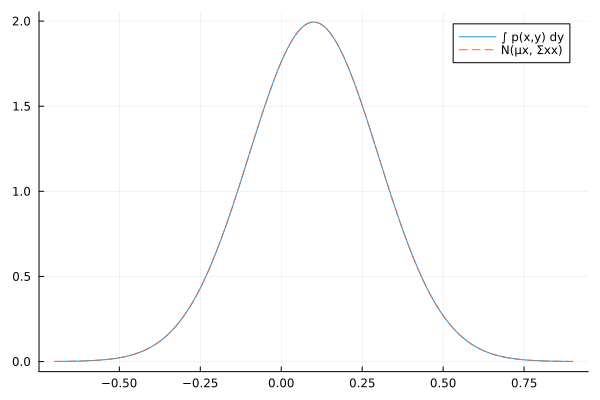

print device already activated


In [36]:
# Ex 2.14 check
μ_xy = [0.1, 0.35]
Σ_xy = [0.04 0.01;
        0.01 0.09]

dist_xy = MvNormal(μ_xy, Σ_xy)
dist_x = Normal(μ_xy[1], sqrt(Σ_xy[1, 1]))

μ_x = μ_xy[1]
Σ_xx = Σ_xy[1, 1]

sigma_y = sqrt(Σ_xy[2, 2])
delta = 0.01
y_space = μ_xy[2]-10sigma_y:delta:μ_xy[2]+10sigma_y
x_space = μ_x-4sqrt(Σ_xx):delta:μ_x+4sqrt(Σ_xx)
p_margs = [sum(pdf(dist_xy, [x0, y]) for y in y_space) * delta for x0 in x_space]
@assert isapprox(p_margs, pdf.(dist_x, x_space); rtol = 1e-8)

plot(x_space, p_margs, label="∫ p(x,y) dy")
plot!(x_space, pdf.(dist_x, xs), label="N(μx, Σxx)", ls=:dash)



## Exercise 2.15 _(2ed new)_

Show that the $\mathbf{x}$ information-form marginal for a joint Gaussian

$$p(\mathbf{x}, \mathbf{y}) = \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma}) = \mathcal{N}\left(\begin{bmatrix} \boldsymbol{\mu}_x \\ \boldsymbol{\mu}_y \end{bmatrix}, \begin{bmatrix} \boldsymbol{\Sigma}_{xx} & \boldsymbol{\Sigma}_{xy} \\ \boldsymbol{\Sigma}_{yx} & \boldsymbol{\Sigma}_{yy} \end{bmatrix}\right),$$

$$\boldsymbol{\Sigma}^{-1} = \begin{bmatrix} \mathbf{A}_{xx} & \mathbf{A}_{xy} \\ \mathbf{A}_{yx} & \mathbf{A}_{yy} \end{bmatrix}, \qquad \boldsymbol{\Sigma}^{-1}\boldsymbol{\mu} = \begin{bmatrix} \mathbf{b}_x \\ \mathbf{b}_y \end{bmatrix},$$

is

$$\boldsymbol{\Sigma}_{xx}^{-1} = \mathbf{A}_{xx} - \mathbf{A}_{xy}\mathbf{A}_{yy}^{-1}\mathbf{A}_{yx}, \qquad \boldsymbol{\Sigma}_{xx}^{-1}\boldsymbol{\mu}_x = \mathbf{b}_x - \mathbf{A}_{xy}\mathbf{A}_{yy}^{-1}\mathbf{b}_y.$$

In [ ]:
# Ex 2.15 check
mu_xy = [0.1, 0.35]
Sigma_xy = [0.04 0.01;
            0.01 0.09]

dist = MvNormal(mu_xy, Sigma_xy)
A = inv(Sigma_xy)   
b = A * mu_xy
A_xx = A[1,1]
A_xy = A[1,2]
A_yx = A[2,1]
A_yy = A[2,2]
b_x = b[1]
b_y = b[2]


@assert isapprox(A_xx - A_xy * inv(A_yy) * A_yx, inv(Sigma_xy[1,1]); atol=1e-8)
@assert isapprox(b_x - A_xy * inv(A_yy) * b_y,inv(Sigma_xy[1,1])* μ_xy[1]; atol=1e-8)


## Exercise 2.16 _(2ed new)_

One of the key tools that we will use to derive our Bayesian estimators is the so-called 'two-step approach to Bayesian inference'. This question works through that process.

1. Suppose we have a prior, $p(\mathbf{x}) = \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, for a random variable, $\mathbf{x} \in \mathbb{R}^N$. We measure this quantity according to the following measurement model,

   $$\mathbf{y} = \mathbf{C}\mathbf{x} + \mathbf{n},$$

   where $\mathbf{n} \sim \mathcal{N}(\mathbf{0}, \mathbf{R})$ is measurement noise that is statistically independent from $\mathbf{x}$. Provide an expression for $p(\mathbf{y}|\mathbf{x})$.
2. Form the joint likelihood for $\mathbf{x}$ and $\mathbf{y}$ by filling in the following:

   $$p(\mathbf{x}, \mathbf{y}) = p(\mathbf{y}|\mathbf{x})\,p(\mathbf{x}) = \mathcal{N}\left(\begin{bmatrix} ? \\ ? \end{bmatrix}, \begin{bmatrix} ? & ? \\ ? & ? \end{bmatrix}\right).$$
3. Now factor the joint likelihood the other way:

   $$p(\mathbf{x}, \mathbf{y}) = p(\mathbf{x}|\mathbf{y})\,p(\mathbf{y}).$$

   Provide expressions for $p(\mathbf{x}|\mathbf{y})$ and $p(\mathbf{y})$.
4. The Bayesian posterior is $p(\mathbf{x}|\mathbf{y})$. Looking at this expression, will the covariance be larger or smaller than that of $p(\mathbf{x})$? Explain briefly.

### Derivation

**(i) Measurement model.** Given $\mathbf{x}$, $\mathbf{C}\mathbf{x}$ is a constant and $\mathbf{n}$ is the only randomness: constant + noise shifts the mean, keeps the covariance.

$$p(\mathbf{y}|\mathbf{x}) = \mathcal{N}(\mathbf{C}\mathbf{x}, \mathbf{R}).$$

As a function of $\mathbf{y}$ (fixed $\mathbf{x}$) this is the sensor model; as a function of $\mathbf{x}$ (fixed $\mathbf{y}_{\text{meas}}$) it is the likelihood.

**(ii) Joint.** Stack the independent Gaussians $\mathbf{x}$ and $\mathbf{n}$ and apply a linear map:

$$\begin{bmatrix} \mathbf{x} \\ \mathbf{n} \end{bmatrix} \sim \mathcal{N}\left(\begin{bmatrix} \boldsymbol{\mu} \\ \mathbf{0} \end{bmatrix}, \begin{bmatrix} \boldsymbol{\Sigma} & \mathbf{0} \\ \mathbf{0} & \mathbf{R} \end{bmatrix}\right), \qquad \begin{bmatrix} \mathbf{x} \\ \mathbf{y} \end{bmatrix} = \underbrace{\begin{bmatrix} \mathbf{1} & \mathbf{0} \\ \mathbf{C} & \mathbf{1} \end{bmatrix}}_{\mathbf{T}} \begin{bmatrix} \mathbf{x} \\ \mathbf{n} \end{bmatrix}.$$

Linear map of a Gaussian (as in 2.13): mean $\to \mathbf{T}\cdot$mean, covariance $\to \mathbf{T}(\cdot)\mathbf{T}^T$:

$$p(\mathbf{x}, \mathbf{y}) = p(\mathbf{y}|\mathbf{x})\,p(\mathbf{x}) = \mathcal{N}\left(\begin{bmatrix} \boldsymbol{\mu} \\ \mathbf{C}\boldsymbol{\mu} \end{bmatrix}, \begin{bmatrix} \boldsymbol{\Sigma} & \boldsymbol{\Sigma}\mathbf{C}^T \\ \mathbf{C}\boldsymbol{\Sigma} & \mathbf{C}\boldsymbol{\Sigma}\mathbf{C}^T + \mathbf{R} \end{bmatrix}\right).$$

Dimension $N + M$. The off-diagonal block $\boldsymbol{\Sigma}\mathbf{C}^T$ is the correlation through which $\mathbf{y}$ carries information about $\mathbf{x}$.

**(iii) Factor the other way.** Marginal of $\mathbf{y}$ — take the block (2.14):

$$p(\mathbf{y}) = \mathcal{N}(\mathbf{C}\boldsymbol{\mu}, \mathbf{S}), \qquad \mathbf{S} = \mathbf{C}\boldsymbol{\Sigma}\mathbf{C}^T + \mathbf{R}.$$

Conditional of $\mathbf{x}$ — Schur complement of the $\mathbf{y}$ block in covariance form:

$$p(\mathbf{x}|\mathbf{y}) = \mathcal{N}\big(\boldsymbol{\mu} + \mathbf{K}(\mathbf{y} - \mathbf{C}\boldsymbol{\mu}),\; \boldsymbol{\Sigma} - \mathbf{K}\mathbf{C}\boldsymbol{\Sigma}\big), \qquad \mathbf{K} = \boldsymbol{\Sigma}\mathbf{C}^T\mathbf{S}^{-1}.$$

This is the Kalman filter correction step: prior $(\check{\mathbf{x}}, \check{\mathbf{P}}) = (\boldsymbol{\mu}, \boldsymbol{\Sigma})$, innovation $\mathbf{y} - \mathbf{C}\boldsymbol{\mu}$ with covariance $\mathbf{S}$, gain $\mathbf{K}$, posterior covariance $(\mathbf{1} - \mathbf{K}\mathbf{C})\boldsymbol{\Sigma}$. The posterior covariance does not depend on the value of $\mathbf{y}$.

Equivalent information form (SMW identity / fusion as in 2.8):

$$\boldsymbol{\Sigma}_{x|y}^{-1} = \boldsymbol{\Sigma}^{-1} + \mathbf{C}^T\mathbf{R}^{-1}\mathbf{C}.$$

**(iv) Smaller.** Information only adds: $\mathbf{C}^T\mathbf{R}^{-1}\mathbf{C} \succeq \mathbf{0}$, so $\boldsymbol{\Sigma}_{x|y}^{-1} \succeq \boldsymbol{\Sigma}^{-1}$, i.e. $\boldsymbol{\Sigma}_{x|y} \preceq \boldsymbol{\Sigma}$. In covariance form we subtract a PSD term: $\boldsymbol{\Sigma} - \boldsymbol{\Sigma}_{x|y} = \mathbf{K}\mathbf{S}\mathbf{K}^T \succeq \mathbf{0}$. Meaning: variance along every direction $\mathbf{v}$ does not grow, $\mathbf{v}^T\boldsymbol{\Sigma}_{x|y}\mathbf{v} \le \mathbf{v}^T\boldsymbol{\Sigma}\mathbf{v}$.

- Directions in the null space of $\mathbf{C}$ are unobserved: no reduction there (zero eigenvalues of $\boldsymbol{\Sigma} - \boldsymbol{\Sigma}_{x|y}$ when $M < N$).
- $\mathbf{R} \to \infty$: posterior = prior; $\mathbf{R} \to \mathbf{0}$: observed directions collapse.
- Guaranteed for every $\mathbf{y}$ only in the linear-Gaussian case; in general only on average (law of total variance: $\boldsymbol{\Sigma} = E[\boldsymbol{\Sigma}_{x|y}] + \operatorname{Cov}[\boldsymbol{\mu}_{x|y}]$).

In [87]:
# Ex 2.16 check
N = 5
n = 100_000
Random.seed!(161) 
mu_x = [0.1, 0.2, 0.3, 0.4, 0.5]
rnd_mat = randn(N, N)
Sigma_x = Symmetric(rnd_mat * rnd_mat' + 0.1I)

dist_x = MvNormal(mu_x, Sigma_x)

M = 3
C = randn(M, N)
Random.seed!(162) 
rnd_mat = randn(M, M)
R = Symmetric(rnd_mat * rnd_mat' + 0.1I)
dist_n = MvNormal(zeros(M), R)

#x0 is a point, it doesn't have a variance
x0 = rand(dist_x)
y = C * x0 .+ rand(dist_n, n)
@assert isapprox(mean(y, dims=2), C * x0; atol = 0.02)
@assert isapprox(cov(y, dims=2), R; rtol = 0.03)


#(ii)
x = rand(dist_x, n)
y = C * x + rand(dist_n, n)
xy = vcat(x, y)

mu_joint = [mu_x; C * mu_x]
Sigma_joint = [Sigma_x Sigma_x * C';
               C * Sigma_x C * Sigma_x * C' + R]

@assert isapprox(mean(xy, dims=2), mu_joint; atol =5 * sqrt(tr(Sigma_joint) / n))
@assert isapprox(cov(xy, dims=2), Sigma_joint; rtol = 0.03)

#(iii)

mu_y = mu_joint[N+1:end]
Sigma_y = Symmetric(Sigma_joint[N+1:end, N+1:end])
dist_y = MvNormal(mu_y, Sigma_y)
y_meas = rand(dist_y, n)

Sigma_x = Sigma_joint[1:N, 1:N]
Sigma_xy = Sigma_joint[1:N, N+1:end]
K = Sigma_xy / Sigma_y
mu_posterior = mu_x .+ K * (y_meas .- C * mu_x)
Sigma_posterior = Symmetric(Sigma_x - K * Sigma_xy')

j = 1
y1 = y_meas[:, j]
dist_posterior = MvNormal(mu_posterior[:, j], Sigma_posterior)   # p(x | y1)

xt = rand(dist_x)
dist_joint = MvNormal(mu_joint, Symmetric(Sigma_joint))
@assert logpdf(dist_joint, [xt; y1]) ≈ logpdf(dist_posterior, xt) + logpdf(dist_y, y1)


#(iv) sigma_posterior < sigma_prior ?

lambda = eigvals(Symmetric(Sigma_x - Sigma_posterior))
@assert all(lambda .> -1e-10)
tr(Sigma_posterior) < tr(Sigma_x)  
det(Sigma_posterior) < det(Sigma_x)   

true